In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polyscope as ps

from mpl_toolkits.mplot3d import Axes3D
from stl import mesh

import rainbow.math.involute as INVOLUTE

from rainbow.procedural.gears.types import GearSpec
from rainbow.procedural.gears.generators import GearFactory

ps.init()

plt.rc('font', size=12)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.6 (Core Profile) Mesa 24.0.9-0ubuntu0.3


In [2]:
z = 21
m = 2 * 10 / z
spec = GearSpec(m, z, bevel_cone_angle=20)

factory = GearFactory(5, 1, 1)
gear = factory.create_gear(spec, 10, subdivisions=10)
V = gear.V
T = gear.T

m = mesh.Mesh(np.zeros(T.shape[0], dtype=mesh.Mesh.dtype))
for i, f in enumerate(T):
    for j in range(3):
        m.vectors[i][j] = V[f[j], :]
m.save('gear.stl')

ps_mesh = ps.register_surface_mesh("gear", V, gear.T)

# Wireframe rendering
ps_mesh.set_edge_color([0, 0, 0])
ps_mesh.set_edge_width(1)

ps.show()

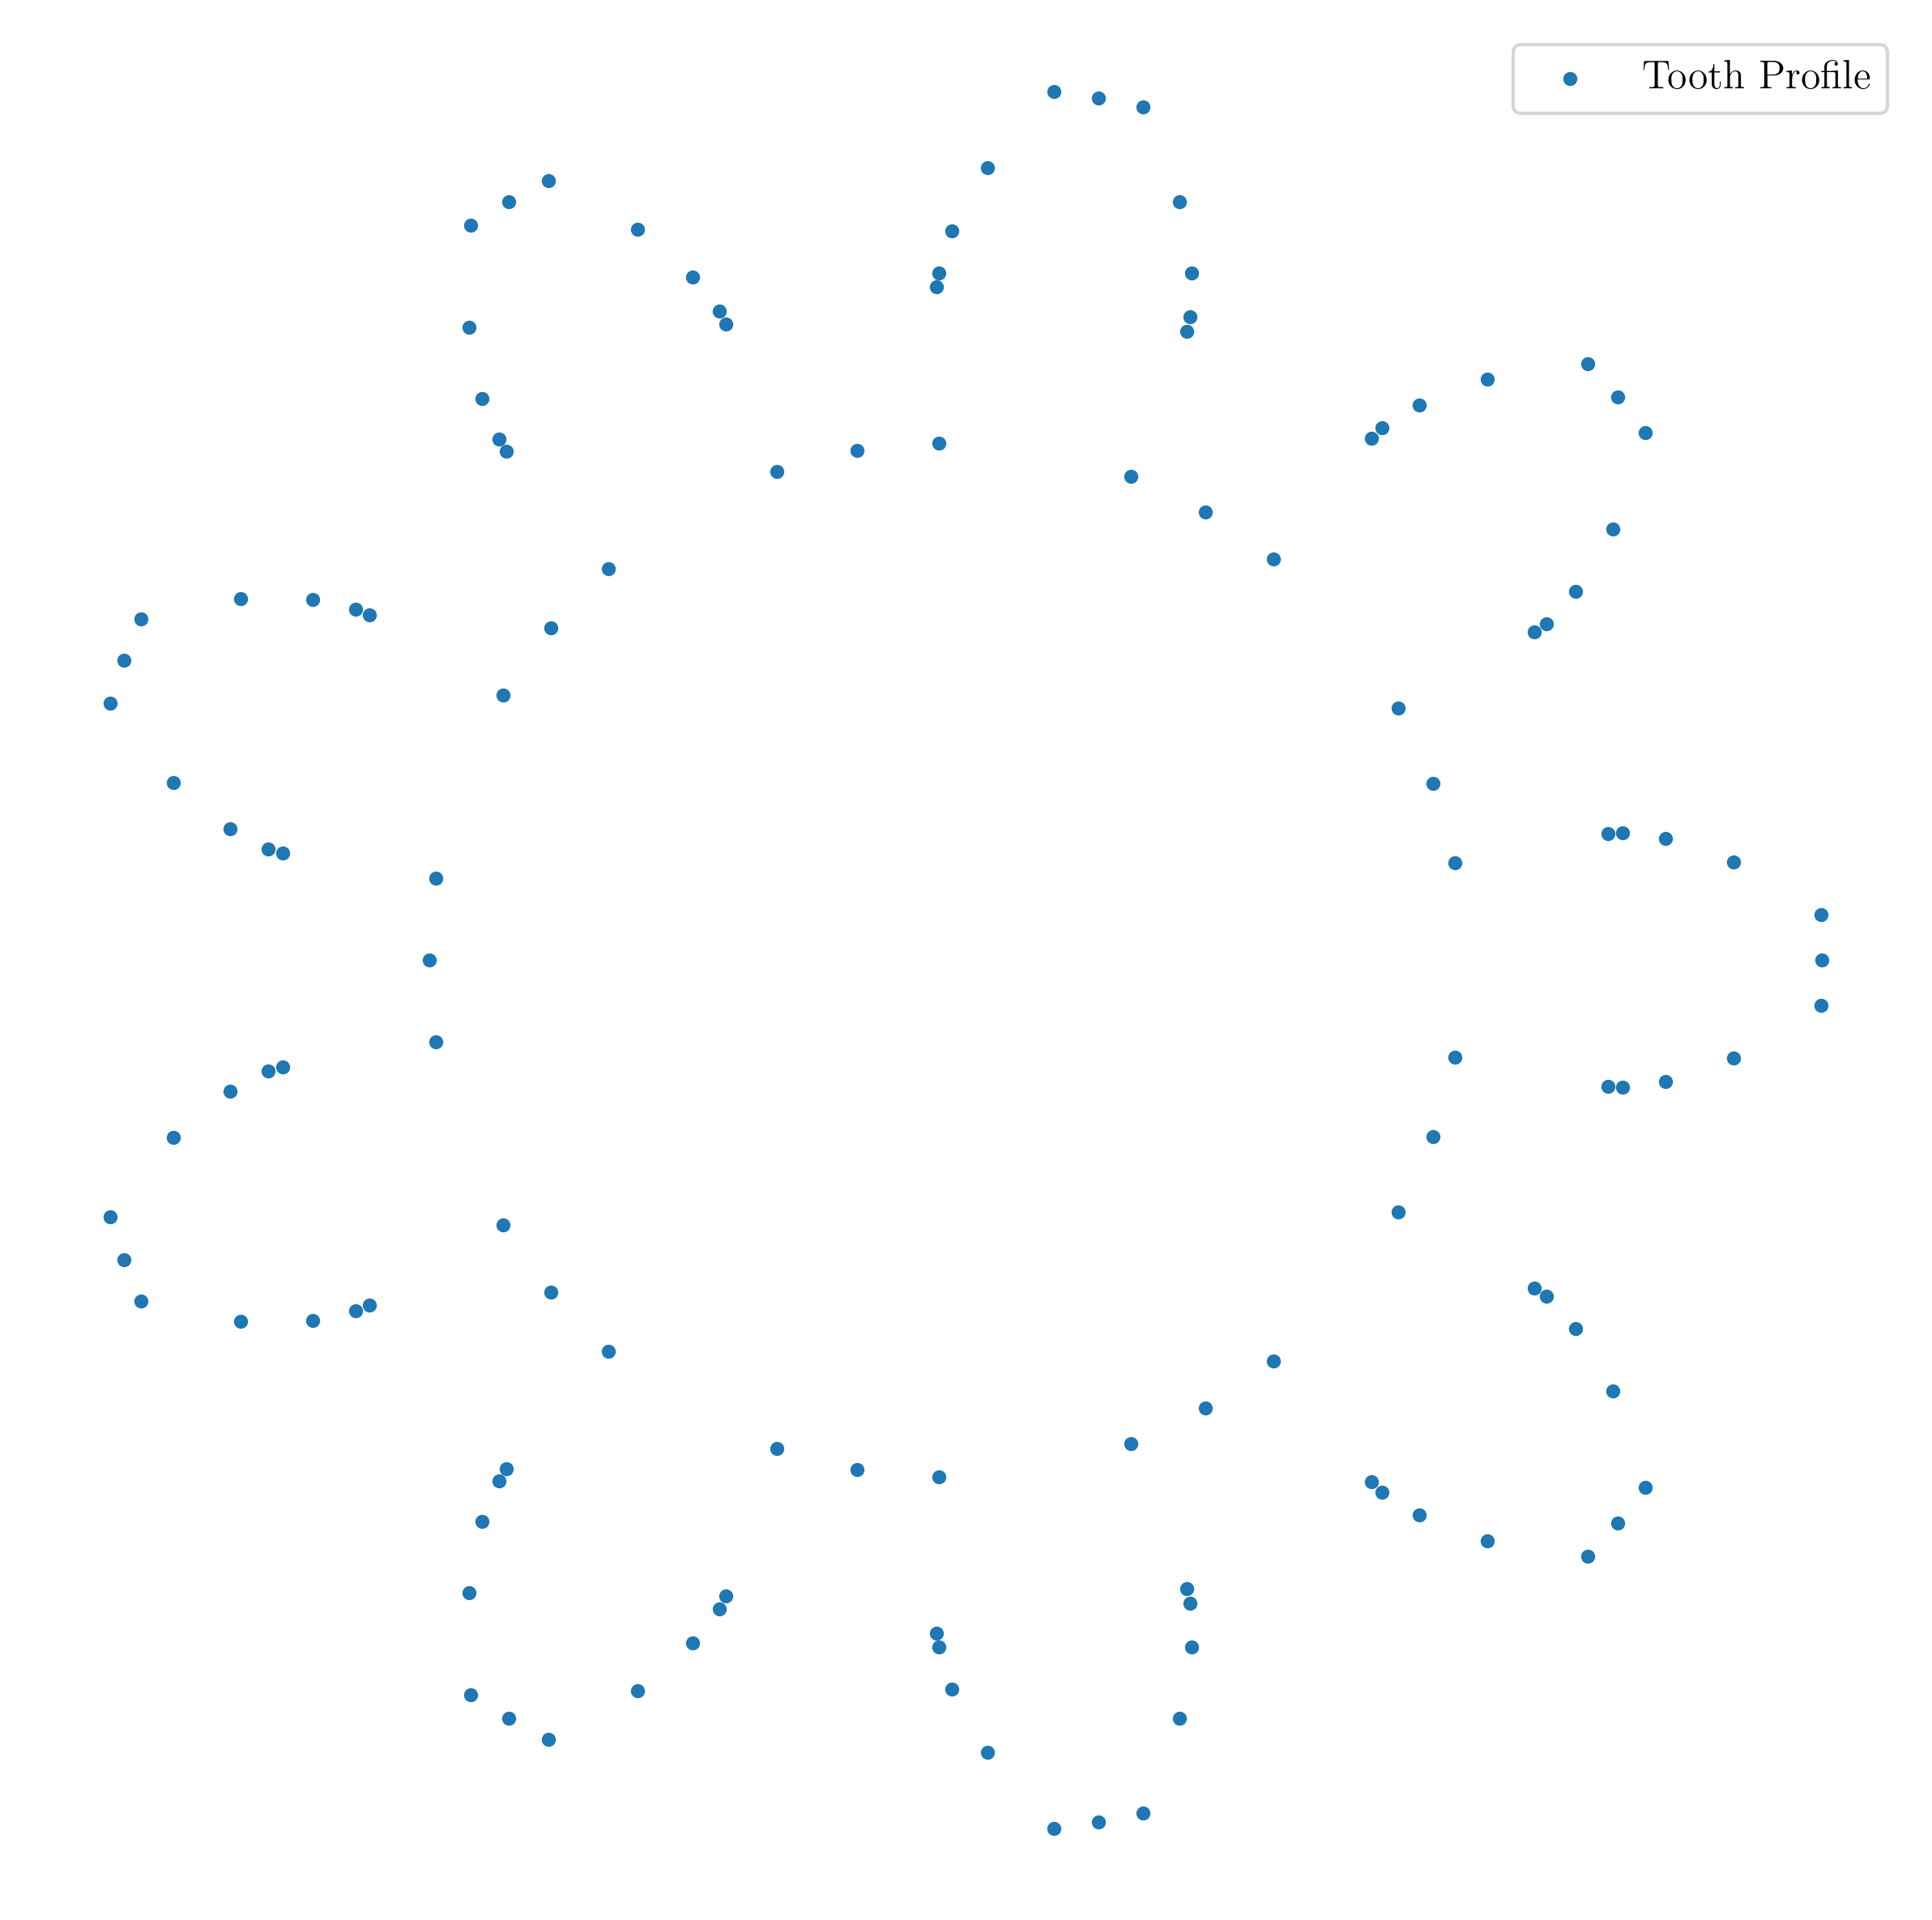

In [3]:
fact = GearFactory(5, 1, 1)
s = GearSpec(1, 9, is_internal=True)
tooth_profile_coordinates = fact._create_profile_points(s)

plt.figure(figsize=(10, 10), dpi=300)
plt.axis('equal')
plt.axis('off')
plt.scatter(tooth_profile_coordinates[:, 0], tooth_profile_coordinates[:, 1], s=10, label='Tooth Profile')
plt.legend()
plt.savefig('gear_profile_sample_points.png', dpi=300)

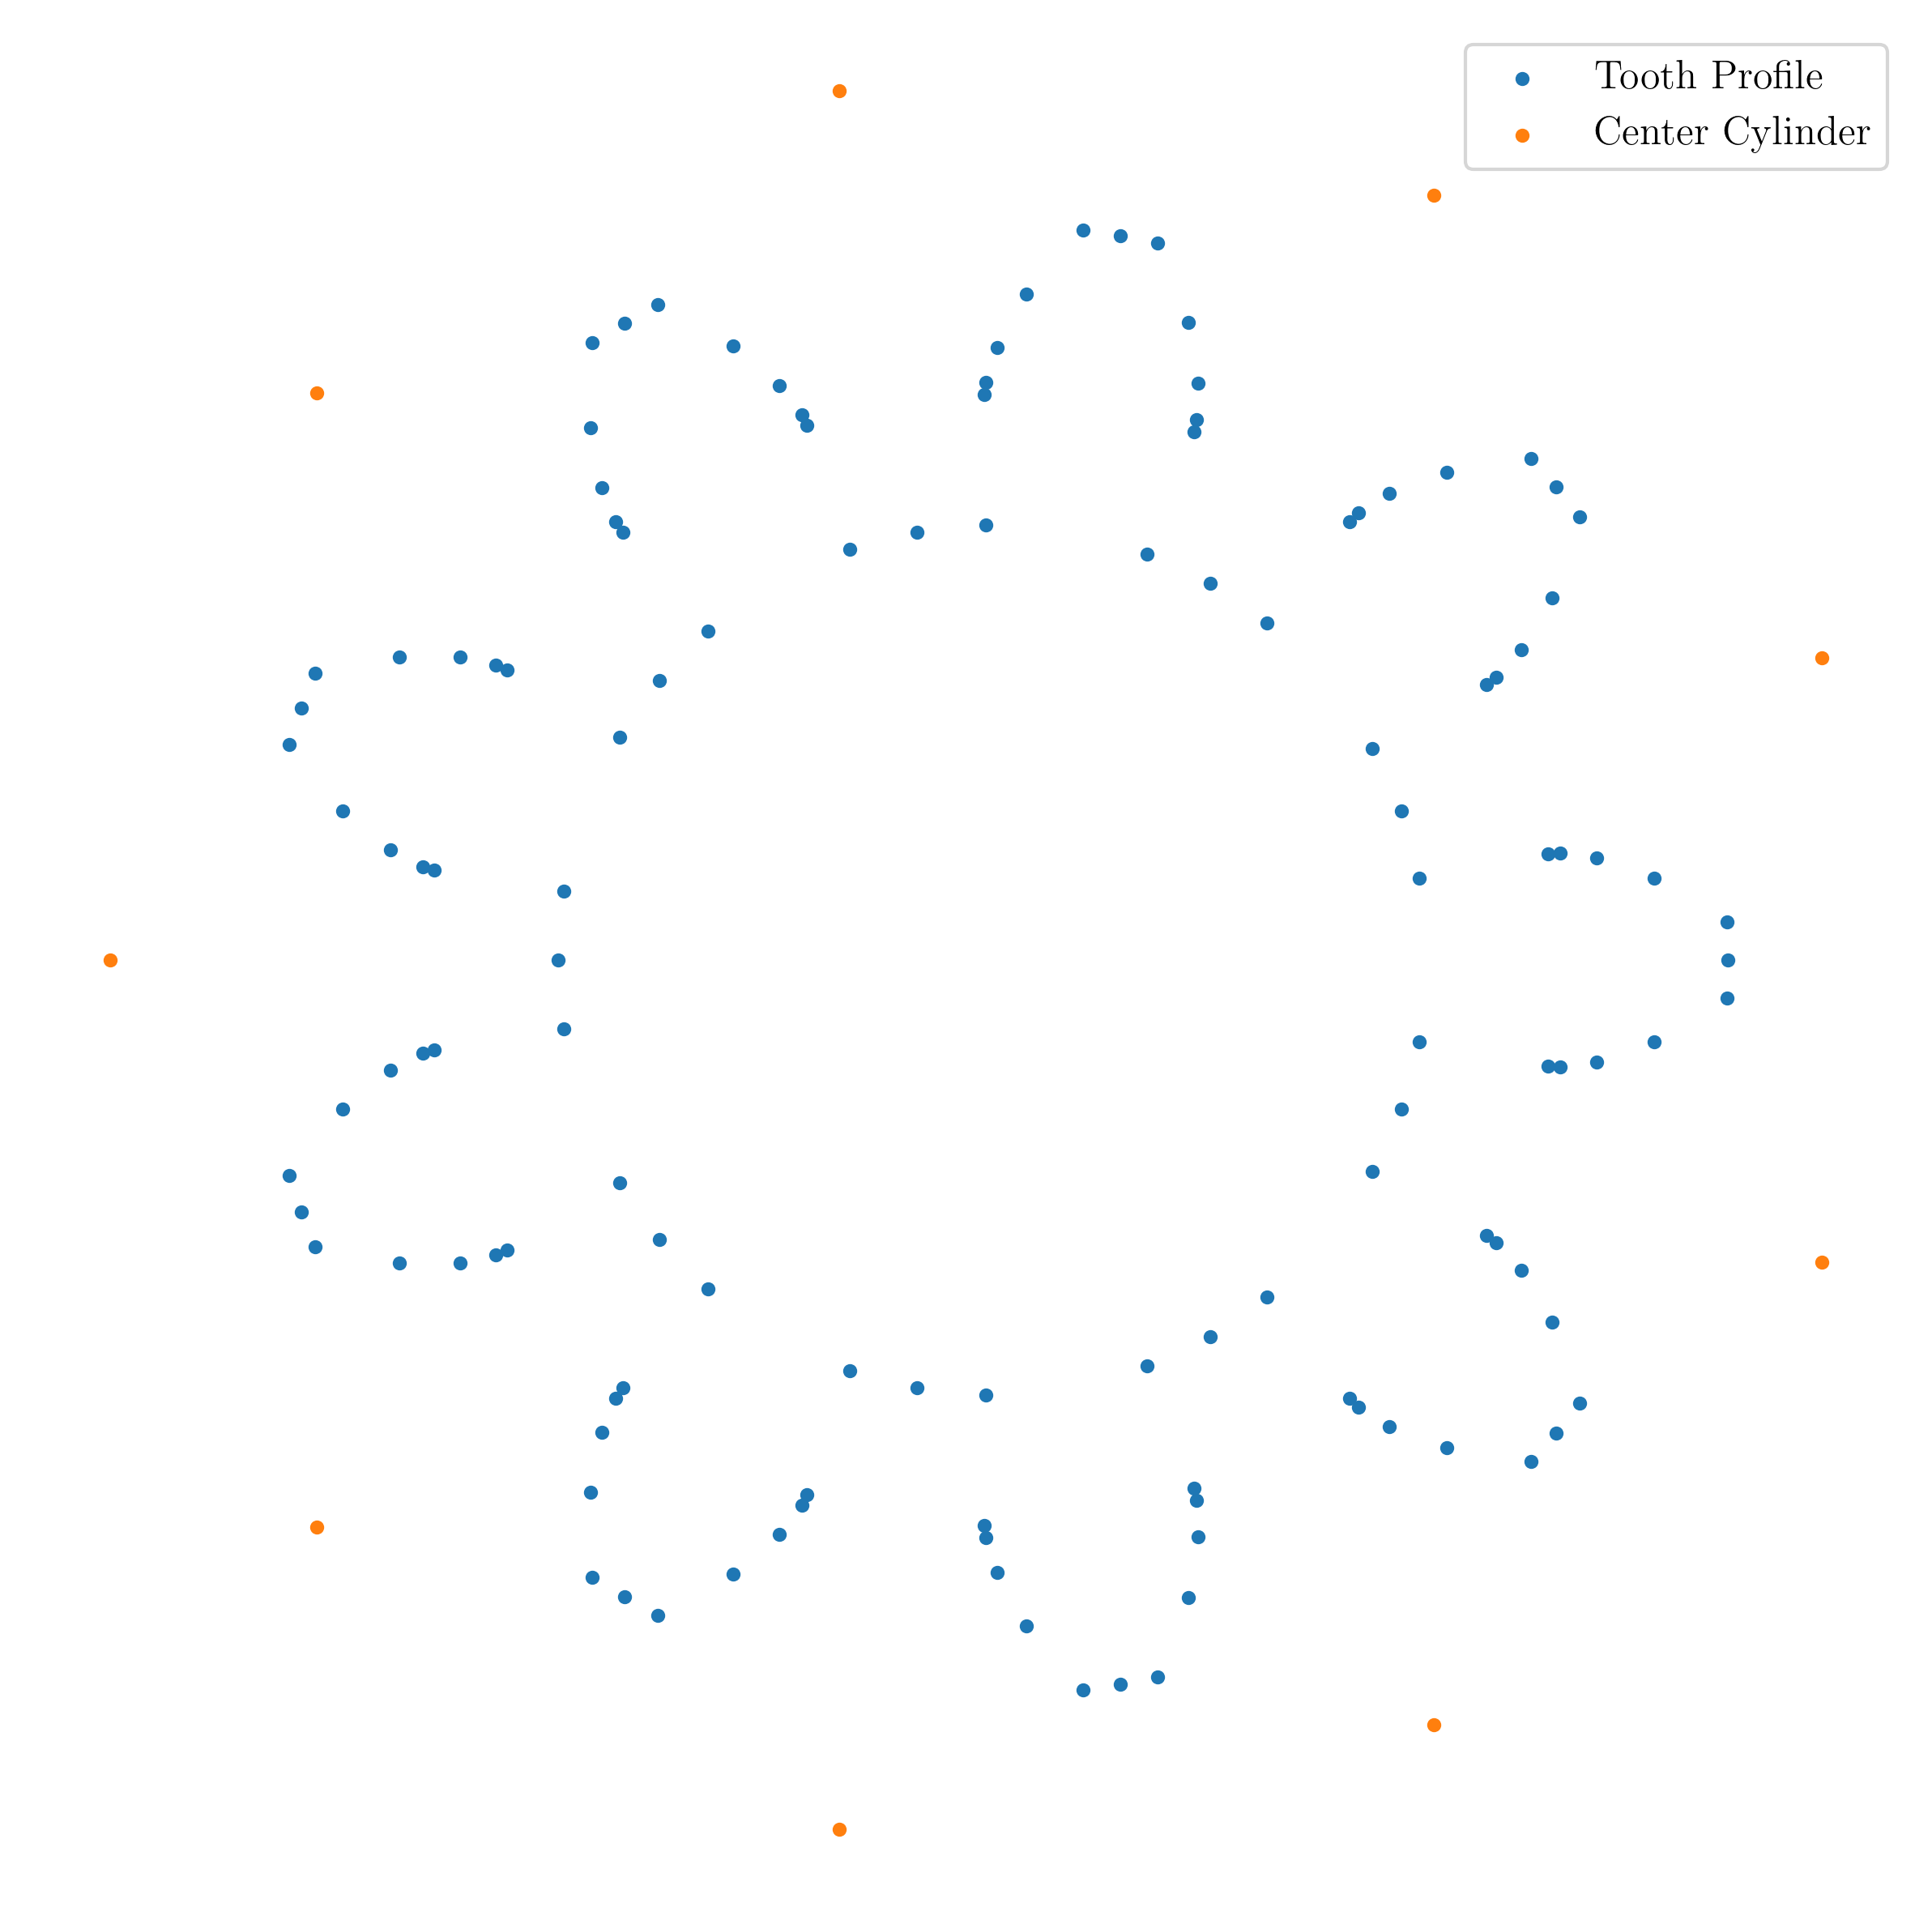

In [4]:
center_cylinder_coordinates = fact._create_cylinder_points(s)

plt.figure(figsize=(10, 10), dpi=300)
plt.axis('equal')
plt.axis('off')
plt.scatter(tooth_profile_coordinates[:, 0], tooth_profile_coordinates[:, 1], s=10, label='Tooth Profile')
plt.scatter(center_cylinder_coordinates[:, 0], center_cylinder_coordinates[:, 1], s=10, label='Center Cylinder')
plt.legend()
plt.savefig('gear_profile_sample_points_with_cylinder_internal.png', dpi=300)

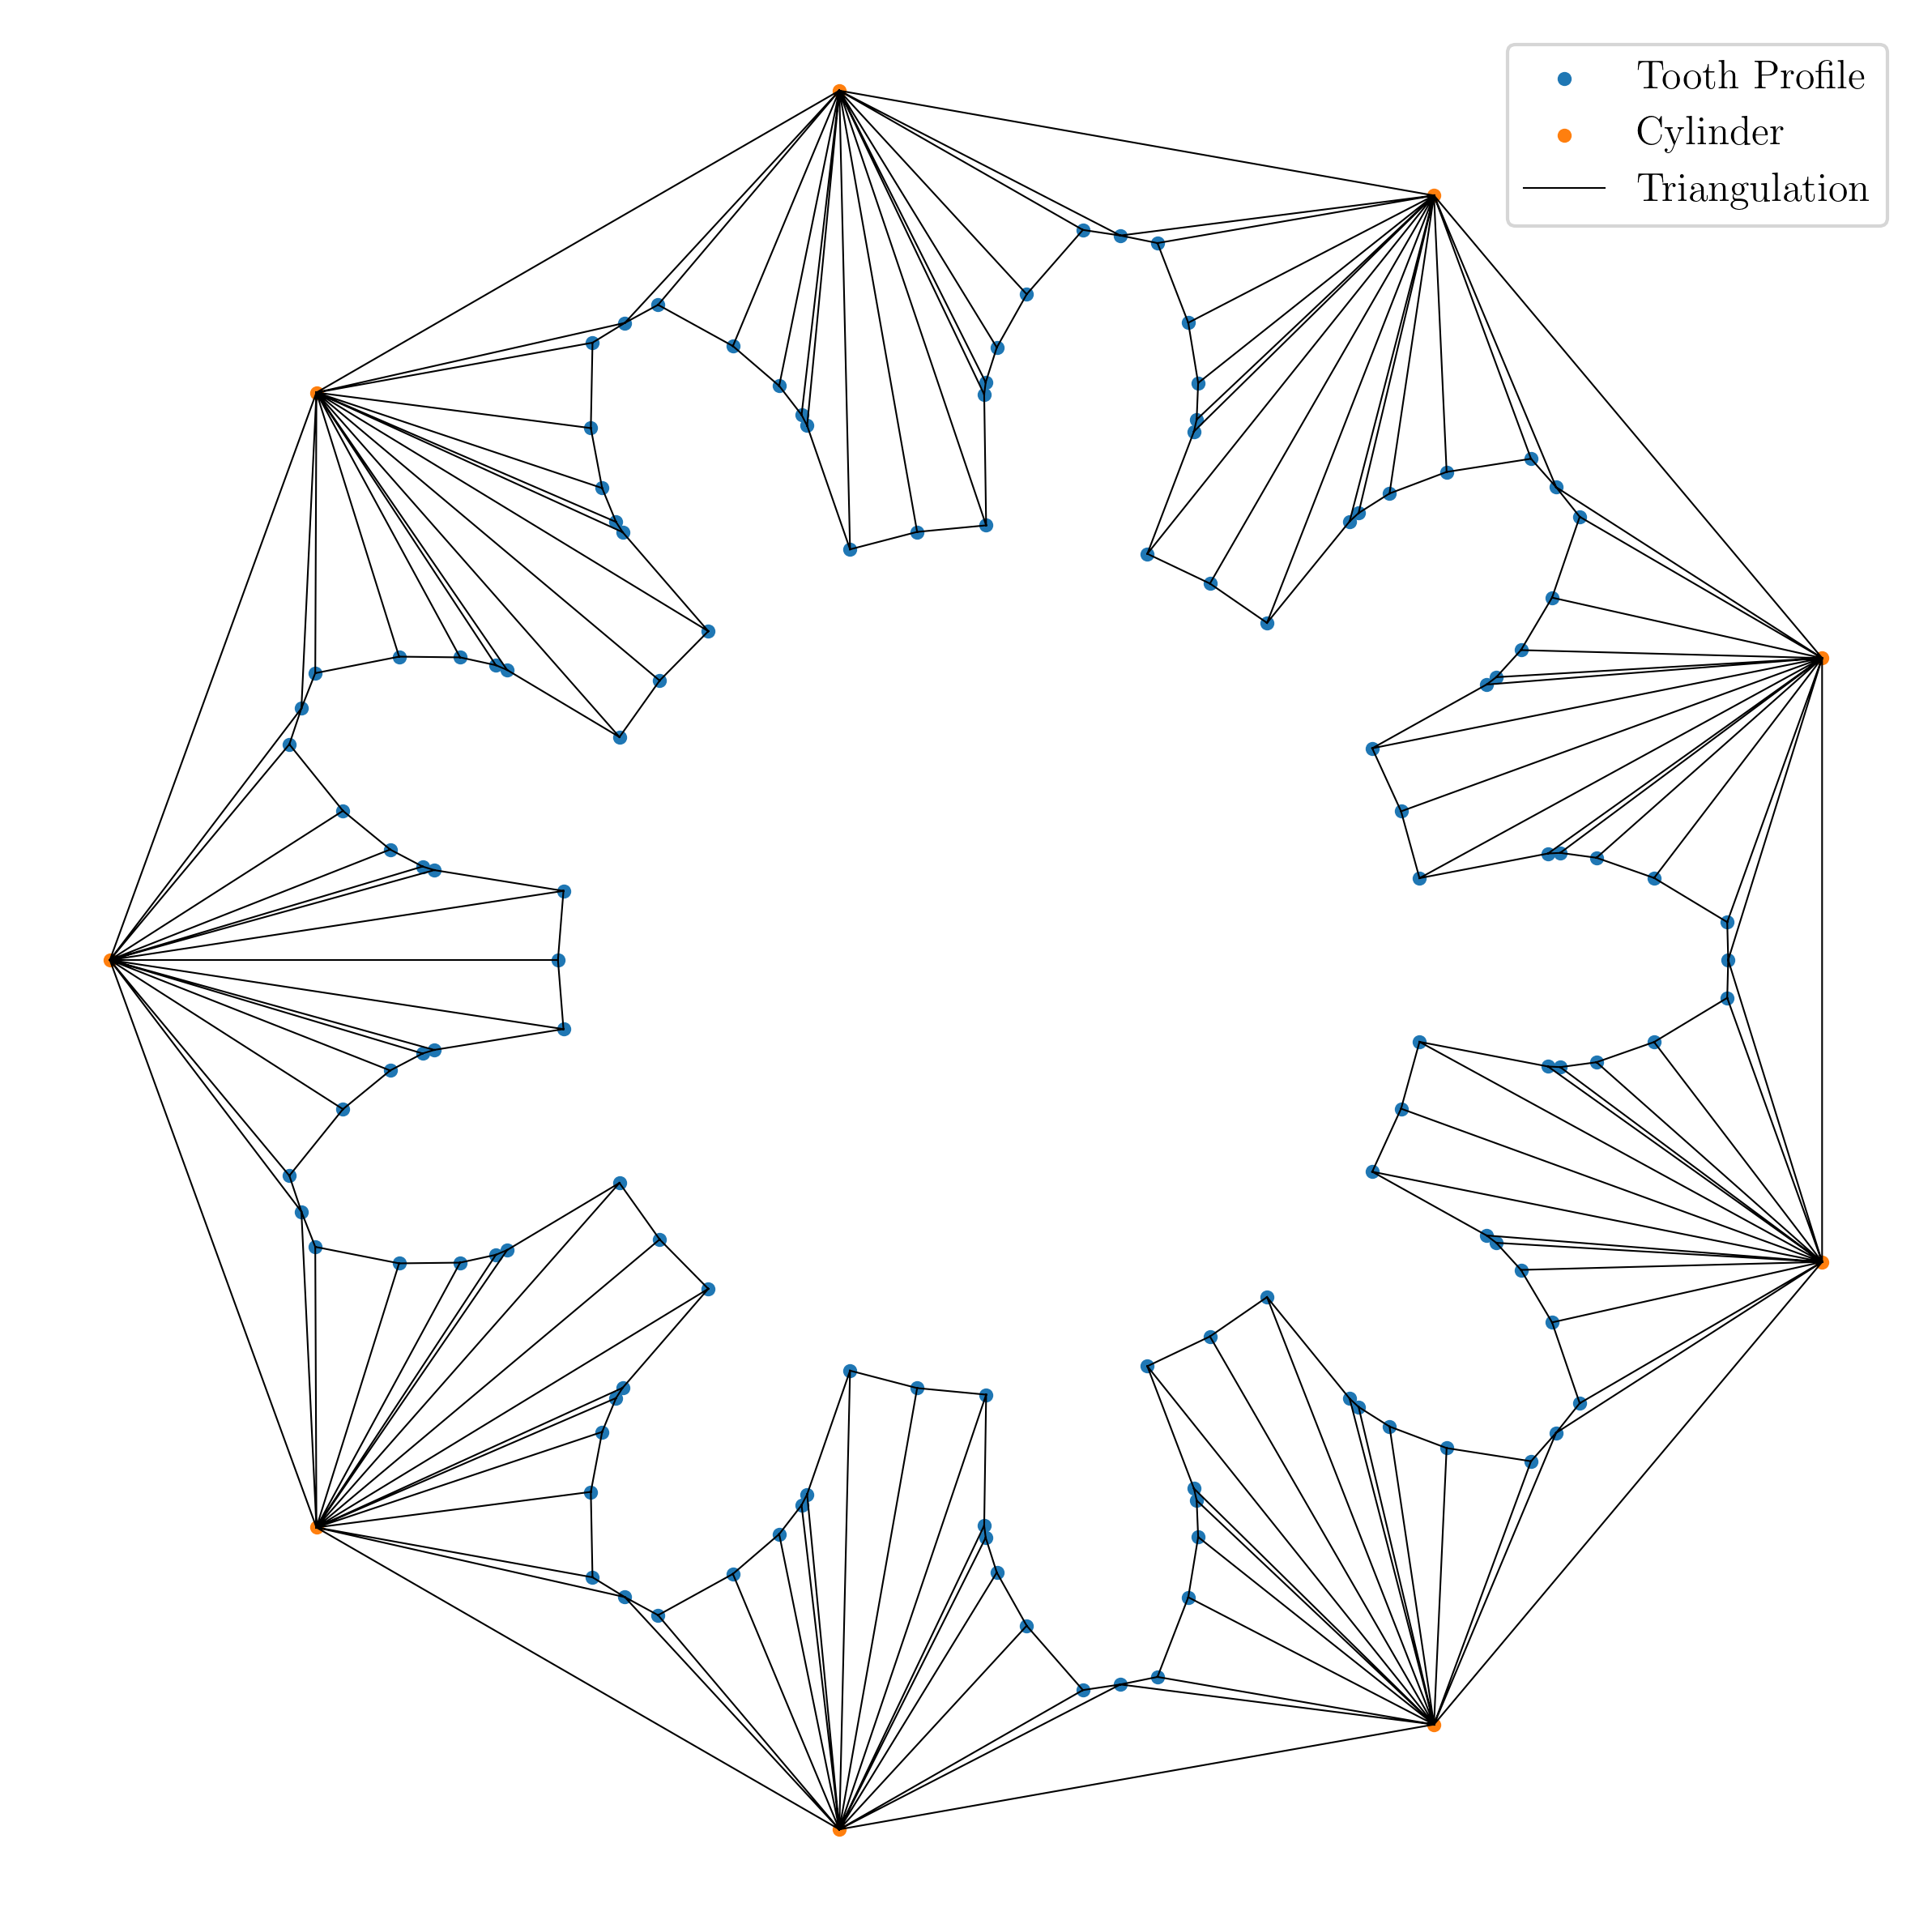

In [5]:
V, T = fact._generate_mesh(s, tooth_profile_coordinates, center_cylinder_coordinates)

plt.figure(figsize=(10, 10), dpi=300)
plt.axis('equal')
plt.axis('off')
plt.scatter(tooth_profile_coordinates[:, 0], tooth_profile_coordinates[:, 1], s=10, label='Tooth Profile')
plt.scatter(center_cylinder_coordinates[:, 0], center_cylinder_coordinates[:, 1], s=10, label='Cylinder')
plt.triplot(V[:, 0], V[:, 1], T, color='black', linewidth=0.5, label='Triangulation')
plt.legend()
plt.savefig('gear_profile_tessellation_internal.png', dpi=300)

In [8]:
def translation_matrix(v: np.ndarray):
    return np.array([
        [1, 0, 0, v[0]],
        [0, 1, 0, v[1]],
        [0, 0, 1, v[2]],
        [0, 0, 0, 1]
    ]).T

def orientation_matrix(v: np.ndarray):
    up = np.array([0, 0, 1])
    
    axis_x = v / np.linalg.norm(v)
    axis_y = np.cross(axis_x, up)
    axis_y /= np.linalg.norm(axis_y)
    axis_z = np.cross(axis_x, axis_y)
    axis_z /= np.linalg.norm(axis_z)
    
    return np.array([
        [axis_x[0], axis_y[0], axis_z[0], 0],
        [axis_x[1], axis_y[1], axis_z[1], 0],
        [axis_x[2], axis_y[2], axis_z[2], 0],
        [0, 0, 0, 1]
    ]).T

def rotation_matrix_y(theta: float):
    theta *= -1
    return np.array([
        [np.cos(theta), 0, np.sin(theta), 0],
        [0, 1, 0, 0],
        [-np.sin(theta), 0, np.cos(theta), 0],
        [0, 0, 0, 1]
    ]).T

spec = GearSpec(1, 21, bevel_cone_angle=20)
factory = GearFactory(5, 1, 1)

face_width = 10

gear = factory.create_gear(spec, face_width, subdivisions=3)

theta = np.deg2rad(20)

R = spec.rp
H = (R / np.tan(theta))

def transform_coords(coords: np.ndarray) -> np.ndarray:
    xy = np.copy(coords[:2])
    xy_norm = np.linalg.norm(xy)
    
    z = coords[2]
    cone_radius = z * spec.rd / H
    
    xy /= xy_norm
    
    cone_point = cone_radius * xy
    cone_point = np.append(cone_point, z)
    
    M_tran = translation_matrix(cone_point)
    M_tran_inv = np.linalg.inv(M_tran)
    M_orie = orientation_matrix(cone_point)
    M_orie_inv = np.linalg.inv(M_orie)
    M_rota = rotation_matrix_y(theta)
    
    M = M_tran_inv @ M_orie_inv @ M_rota @ M_orie @ M_tran
    
    coords_hom = np.append(coords, 1)
    coords_hom = coords_hom @ M
    
    return coords_hom[:3]

V = np.copy(gear.V)
V[:,2] += H

for i in range(len(V)):
    coords = V[i]
    x, y, z = coords
    r = np.sqrt(x**2 + y**2)
    
    r_cone = (R / H) * z
    
    scale = r_cone / spec.rp
    
    coords[:2] *= scale
    
    V[i] = transform_coords(coords)

V[:,2] -= H

ps_mesh = ps.register_surface_mesh("gear", V, gear.T)

# Wireframe rendering
ps_mesh.set_edge_color([0, 0, 0])
ps_mesh.set_edge_width(1)

ps.show()